In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.utils import resample
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
plt.rcParams.update({'font.size': 11})

In [2]:
#load data
df = pd.read_csv('/data/rating_cleaned.csv')

In [3]:
df = df[df['rating'].notna()]

In [4]:
temp = df[df.is_own_profile == False].groupby('user_id')['model'].count().reset_index(name = 'n')
users_remove = temp[temp.n !=5].user_id.values

In [5]:
df = df[~(df.user_id.isin(users_remove))]

In [6]:
temp = df[df.is_own_profile == True].groupby('user_id')['rating'].count().reset_index(name = 'n')
users_keep = temp[temp.n == 12].user_id.values

In [7]:
df = df[df.user_id.isin(users_keep)]
df.user_id.nunique()

64

In [8]:
temp = df[df.is_own_profile == False].groupby('user_id')['rating'].median().reset_index(name = 'baseline')
df = df.merge(temp, on = 'user_id')
df['delta_rating'] = df['rating'] - df['baseline']

In [9]:
dfs = []
i = 0

seeds = [1,2,3,4,5]
half_lives = [4,14,30,64]
for seed in seeds:
    for hl in half_lives:
        data = pd.read_csv('output/embeddinggemma-300m/seed'+str(seed)+'/results_hafl_life_'+str(hl)+'.csv')
        data.columns = data.columns.str.lstrip()
        data['half_life'] = hl
        data['seed'] = seed
        data['temp'] = data['model']
        data['model'] = data['time_window']
        data['time_window'] = data['temp']
        data.drop(columns='temp', inplace=True)
        dfs.append(data)

In [10]:
data = pd.concat(dfs)

In [11]:
data.head()

,user_id,time_window,model,recall@10,ndcg@10,half_life,seed
0,391859,30.0,deepseek-r1,0.0,0.00000,4,1
1,391859,30.0,gemini-2.0-flash,0.3,0.24573,4,1
2,391859,30.0,llama3.2:3b-instruct-q8_0,0.3,0.34370,4,1
3,391859,90.0,deepseek-r1,0.3,0.24655,4,1
4,391859,90.0,gemini-2.0-flash,0.3,0.24655,4,1


In [12]:
data = data.groupby(['user_id','time_window','model','half_life'])[['recall@10','ndcg@10']].mean().reset_index()

In [13]:
data = data[data.user_id.isin(df.user_id.unique())]

In [14]:
temp = data.merge(df[df.is_own_profile == True][['user_id','model', 'time_window', 'delta_rating']], on = ['user_id','model', 'time_window'])
temp.head()

,user_id,time_window,model,half_life,recall@10,ndcg@10,delta_rating
0,391859,30.0,deepseek-r1,4,0.04,0.025448,4.0
1,391859,30.0,deepseek-r1,14,0.04,0.025448,4.0
2,391859,30.0,deepseek-r1,30,0.04,0.025448,4.0
3,391859,30.0,deepseek-r1,64,0.08,0.056326,4.0
4,391859,30.0,gemini-2.0-flash,4,0.26,0.204886,6.0


In [15]:
from sklearn.utils import resample
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

rows = ['recall@10', 'ndcg@10']
scaler = MinMaxScaler()
predictor = 'delta_rating'
n_bootstrap = 1000
results = []

scaler.fit(temp[rows])
temp[rows] = scaler.transform(temp[rows])

# Loop over both model and half_life
for model in temp.model.unique():
    for half_life in temp.half_life.unique():
        temp2 = temp[(temp.model == model) & (temp.half_life == half_life)].dropna().copy()
        
        if len(temp2) < 10:
            continue
        
        for outcome in tqdm(rows, desc=f"{model} - HL:{half_life}"):
            coefs = []
            for _ in range(n_bootstrap):
                sample = resample(temp2)
                x_sample = sample[predictor].values.reshape(-1, 1)
                y_sample = sample[outcome].values
                reg = LinearRegression().fit(x_sample, y_sample)
                coefs.append(reg.coef_[0])
            
            coefs = np.array(coefs)
            results.append({
                'model': model,
                'half_life': half_life,
                'outcome': outcome,
                'mean': np.mean(coefs),
                'ci_lower': np.percentile(coefs, 2.5),
                'ci_upper': np.percentile(coefs, 97.5)
            })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Clean model names
results_df['plot_model'] = 'llama'
results_df.loc[results_df.model == 'deepseek-r1', 'plot_model'] = 'deepseek'
results_df.loc[results_df.model == 'gemini-2.0-flash', 'plot_model'] = 'gemini'

# Plotting config
plt.rcParams.update({'font.size': 12})

models = results_df['plot_model'].unique()
palette = sns.color_palette("Set1", n_colors=len(models))
model_colors = dict(zip(models, palette))
model_markers = {
    'deepseek': 'o',
    'gemini': 'x',
    'llama': 's'
}

llama3.2:3b-instruct-q8_0 - HL:64: 100%|█████████████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.91s/it]


In [19]:
plt.rcParams.update({'font.size': 11})

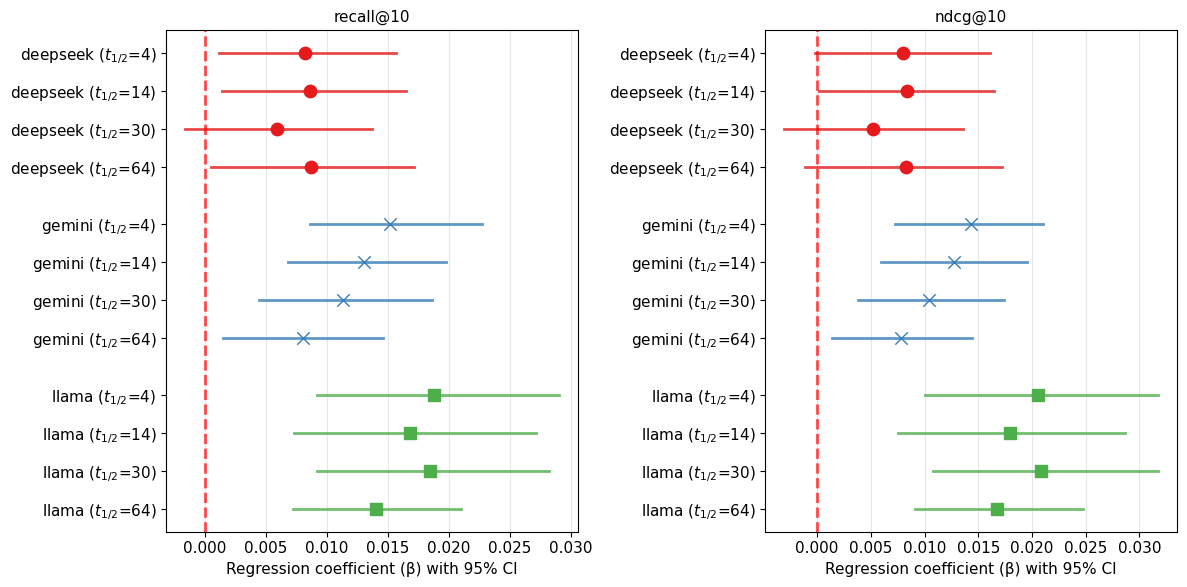

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for idx, outcome in enumerate(['recall@10', 'ndcg@10']):
    ax = axes[idx]
    
    data = results_df[results_df['outcome'] == outcome].copy()
    data = data.sort_values(['plot_model', 'half_life'])
    
    # Create categorical y-positions
    y_pos = 0
    yticks = []
    ylabels = []
    
    for model in models:
        model_data = data[data['plot_model'] == model].sort_values('half_life')
        
        for _, row in model_data.iterrows():
            # Plot point and CI
            ax.plot([row['ci_lower'], row['ci_upper']], [y_pos, y_pos], 
                   color=model_colors[model], linewidth=2, alpha=0.8)
            ax.scatter(row['mean'], y_pos, 
                      marker=model_markers[model], 
                      color=model_colors[model], 
                      s=80, zorder=3, linewidth=1)
            
            yticks.append(y_pos)
            ylabels.append(f"{model} ($t_{{1/2}}$={row['half_life']})")
            y_pos += 1
        
        y_pos += 0.5  # Add space between models
    
    ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=11)
    ax.set_xlabel('Regression coefficient (β) with 95% CI', fontsize=11)
    ax.set_title(outcome, fontsize=11)
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('coefficient_plot_forest.pdf', dpi=300, bbox_inches='tight')
plt.show()